# 🏥 Hospital Readmission Prediction
## Phase 4: SHAP Explainability

**Goal**: Explain *why* the model flags a patient as high-risk — globally and per-patient.  
**Input**: `models/best_model.pkl`, `data/processed/X_test.csv`, `data/processed/y_test.csv`  
**Output**: Publication-quality SHAP plots + `models/shap_values.pkl`

> 💡 **Why SHAP?** Clinicians and hospital administrators don't trust black-box models.
> SHAP (SHapley Additive exPlanations) provides mathematically guaranteed, consistent
> feature attributions — turning a complex model into actionable clinical insight.

---
### Notebook Structure
1. Setup & Load Artifacts
2. Compute SHAP Values
3. Global Explainability — Bar Plot
4. Global Explainability — Beeswarm Plot
5. Global Explainability — Heatmap
6. Feature Interaction — Dependence Plots
7. Per-Patient Explainability — Waterfall Plot
8. Per-Patient Explainability — Force Plot
9. High-Risk vs Low-Risk Patient Comparison
10. Clinical Insights Summary

---
## 1. Setup & Load Artifacts

In [2]:
pip install shap

   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
    --------------------------------------- 0.3/15.6 MB ? eta -:--:--
   -- ------------------------------------- 0.8/15.6 MB 2.0 MB/s eta 0:00:08
   --- ------------------------------------ 1.3/15.6 MB 2.1 MB/s eta 0:00:07
   ---- ----------------------------------- 1.8/15.6 MB 2.2 MB/s eta 0:00:07
   ----- ---------------------------------- 2.1/15.6 MB 2.2 MB/s eta 0:00:07
   ------- -------------------------------- 2.9/15.6 MB 2.3 MB/s eta 0:00:06
   -------- ------------------------------- 3.1/15.6 MB 2.3 MB/s eta 0:00:06
   --------- ------------------------------ 3.7/15.6 MB 2.2 MB/s eta 0:00:06
   ---------- ----------------------------- 4.2/15.6 MB 2.2 MB/s eta 0:00:06
   ----------- ---------------------------- 4.5/15.6 MB 2.2 MB/s eta 0:00:06
   ------------ --------------------------- 5.0/15.6 MB 2.2 MB/s eta 0:00:05
   -------------- ------------------------- 5.5/15.6 MB 2.2 MB/s eta 0:00:05
   ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
langchain 0.1.16 requires numpy<2,>=1, but you have numpy 2.0.2 which is incompatible.
langchain-community 0.0.38 requires numpy<2,>=1, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires packaging<25,>=20, but you have packaging 26.0 which is incompatible.


In [7]:
import pandas as pd
import numpy as np
import joblib, os, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap

os.makedirs('plots/shap', exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

# Initialise SHAP JS (needed for force plots in Jupyter)
shap.initjs()

print('✅ Libraries loaded')

✅ Libraries loaded


In [4]:
import sys
print(sys.executable)

import numpy
print(numpy.__version__)
print(numpy.__file__)

C:\Users\omc\anaconda3\python.exe
1.26.4
C:\Users\omc\anaconda3\Lib\site-packages\numpy\__init__.py


In [5]:
import numpy as np
print("NumPy OK")

import pandas as pd
print("Pandas OK")

import matplotlib.pyplot as plt
print("Matplotlib OK")

import seaborn as sns
print("Seaborn OK")

import joblib
print("Joblib OK")

import shap
print("SHAP OK")

NumPy OK
Pandas OK
Matplotlib OK
Seaborn OK
Joblib OK
SHAP OK


In [6]:
import sys
print(sys.executable)

C:\Users\omc\anaconda3\python.exe


In [8]:
# ── Load Model Artifact ───────────────────────────────────────────────────────
artifact = joblib.load('models/best_model.pkl')

model         = artifact['model']
threshold     = artifact['threshold']
feature_names = artifact['feature_names']
model_name    = artifact['model_name']

print(f'Model      : {model_name}')
print(f'Threshold  : {threshold:.2f}')
print(f'Features   : {len(feature_names)}')

# ── Load Test Data ────────────────────────────────────────────────────────────
X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

print(f'\nTest set   : {X_test.shape[0]:,} rows')
print(f'Positive % : {y_test.mean()*100:.1f}%')

Model      : LightGBM
Threshold  : 0.04
Features   : 80

Test set   : 14,303 rows
Positive % : 8.8%


In [9]:
# ── Sample for SHAP (TreeExplainer is fast; still cap at 2000 for speed) ──────
SHAP_SAMPLE = min(2000, len(X_test))

idx_sample  = np.random.choice(len(X_test), SHAP_SAMPLE, replace=False)
X_shap      = X_test.iloc[idx_sample].reset_index(drop=True)
y_shap      = y_test.iloc[idx_sample].reset_index(drop=True)

print(f'SHAP sample: {len(X_shap):,} rows')
print(f'Positive %  in sample: {y_shap.mean()*100:.1f}%')

SHAP sample: 2,000 rows
Positive %  in sample: 9.1%


---
## 2. Compute SHAP Values

We use `TreeExplainer` — the exact (not approximate) explainer for tree-based models.
It's orders of magnitude faster than `KernelExplainer` and provides theoretically exact Shapley values.

In [10]:
# ── TreeExplainer ─────────────────────────────────────────────────────────────
print('Computing SHAP values...')

# For Pipeline models (e.g. LR), extract the final estimator
from sklearn.pipeline import Pipeline
if isinstance(model, Pipeline):
    explainer_model = model.named_steps[list(model.named_steps.keys())[-1]]
    X_shap_transformed = model[:-1].transform(X_shap)
    X_shap_for_plot = pd.DataFrame(X_shap_transformed, columns=feature_names)
else:
    explainer_model  = model
    X_shap_for_plot  = X_shap

explainer   = shap.TreeExplainer(explainer_model)
shap_values = explainer(X_shap_for_plot)

# For binary classification, extract class-1 SHAP values
if len(shap_values.shape) == 3:
    sv = shap_values[:, :, 1]   # class 1 = readmitted
else:
    sv = shap_values

print(f'✅ SHAP values computed — shape: {sv.values.shape}')
print(f'   Base value (expected model output): {sv.base_values[0]:.4f}')

Computing SHAP values...
C extension was not built during install!
✅ SHAP values computed — shape: (2000, 80)
   Base value (expected model output): 2.6406


In [11]:
# ── Save SHAP Values ──────────────────────────────────────────────────────────
shap_artifact = {
    'shap_values'   : sv,
    'X_shap'        : X_shap_for_plot,
    'y_shap'        : y_shap,
    'feature_names' : feature_names,
    'base_value'    : float(sv.base_values[0]),
}
joblib.dump(shap_artifact, 'models/shap_values.pkl')
print('✅ Saved to models/shap_values.pkl')

✅ Saved to models/shap_values.pkl


---
## 3. Global Explainability — Bar Plot

**What it shows**: The top features driving readmission predictions across *all* patients, ranked by mean absolute SHAP value (i.e. average impact on model output).

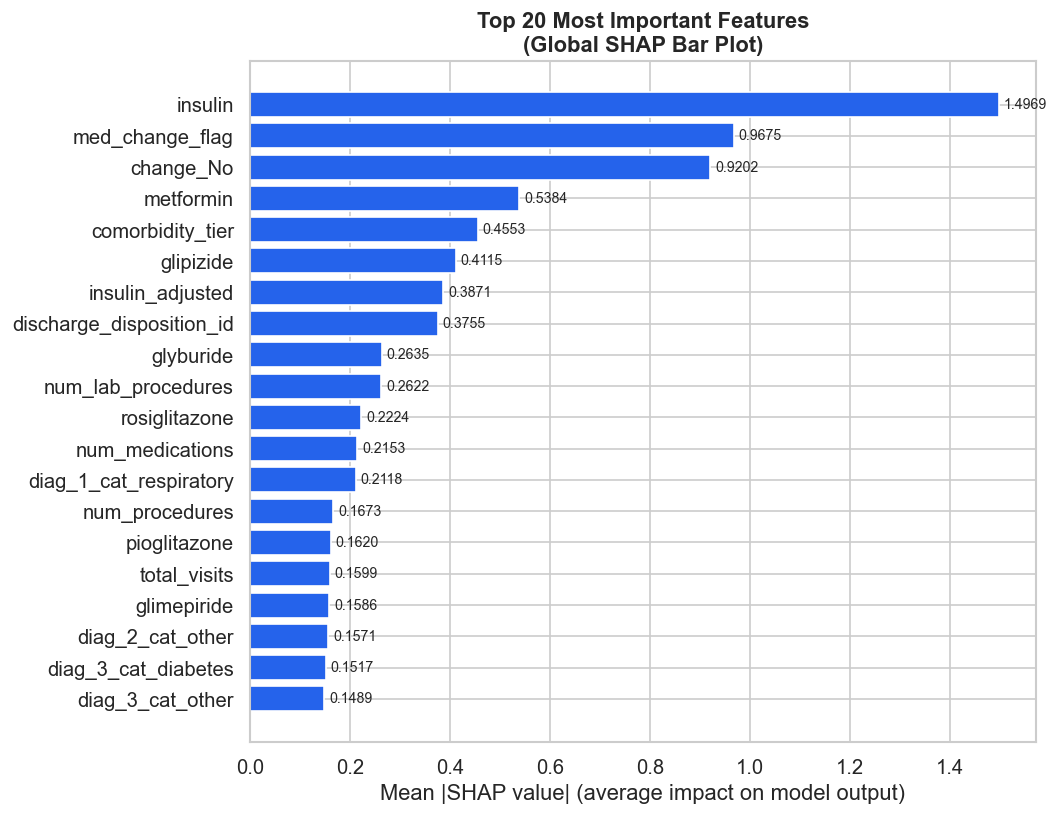


Top 10 features by mean |SHAP|:
insulin                     1.496899
med_change_flag             0.967532
change_No                   0.920160
metformin                   0.538358
comorbidity_tier            0.455319
glipizide                   0.411523
insulin_adjusted            0.387099
discharge_disposition_id    0.375510
glyburide                   0.263536
num_lab_procedures          0.262174


In [12]:
# ── SHAP Bar Plot — Top 20 Features ──────────────────────────────────────────
mean_abs_shap = pd.Series(
    np.abs(sv.values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

TOP_N = 20
top_features = mean_abs_shap.head(TOP_N)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(
    top_features.index[::-1],
    top_features.values[::-1],
    color='#2563EB', edgecolor='white'
)
ax.bar_label(bars, fmt='{:.4f}', padding=3, fontsize=8.5)
ax.set_xlabel('Mean |SHAP value| (average impact on model output)')
ax.set_title(f'Top {TOP_N} Most Important Features\n(Global SHAP Bar Plot)', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/shap/01_global_bar.png', bbox_inches='tight')
plt.show()

print('\nTop 10 features by mean |SHAP|:')
print(top_features.head(10).to_string())

---
## 4. Global Explainability — Beeswarm Plot

**What it shows**: Not just *which* features matter, but *how* they matter.
Each dot = one patient. Color = feature value (red = high, blue = low).
Position on x-axis = SHAP value (positive = pushes toward readmission).

This is the **signature SHAP plot** — it tells the full story in one image.

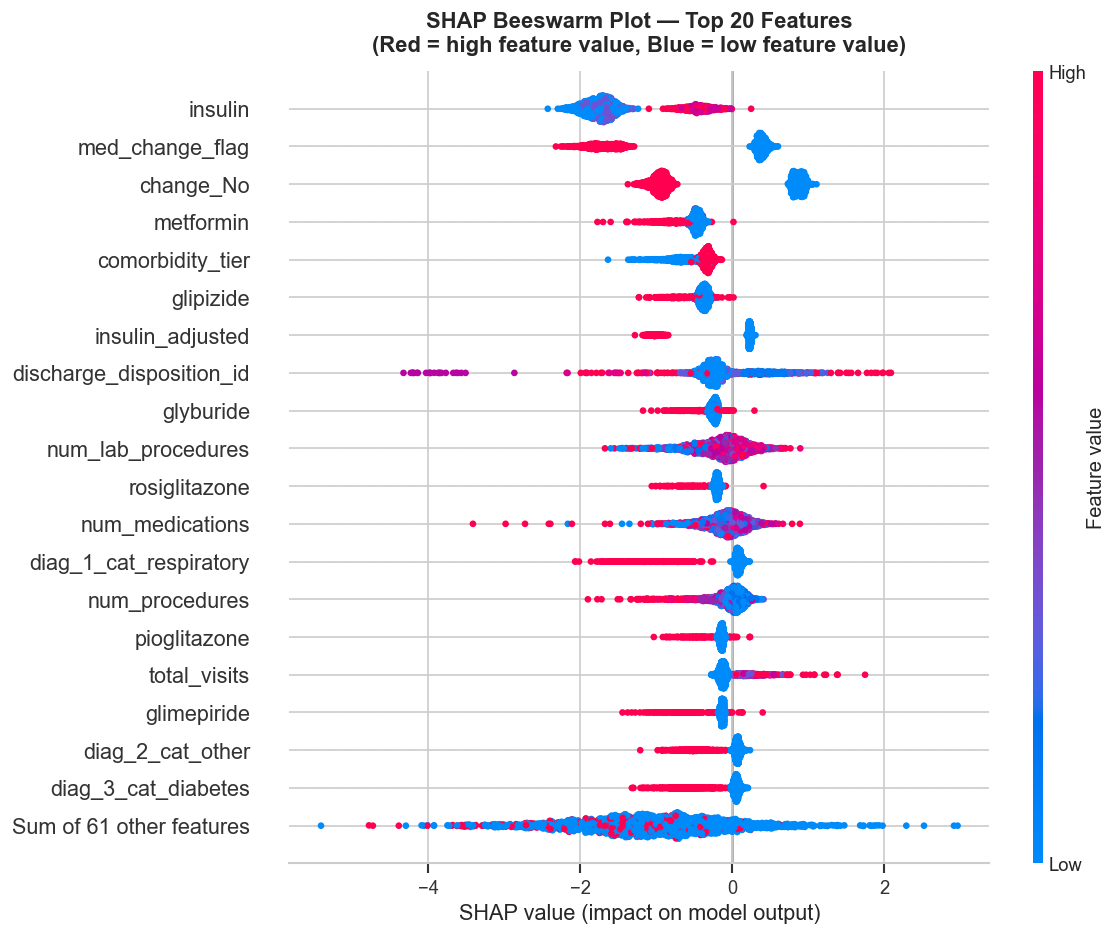


💡 How to read this:
  • Features ranked by global importance (top = most important)
  • Each dot = one patient
  • Red dot on right = high feature value increases readmission risk
  • Blue dot on right = low feature value increases readmission risk


In [13]:
# ── SHAP Beeswarm Plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
shap.plots.beeswarm(
    sv,
    max_display=20,
    show=False,
    plot_size=None
)
plt.title('SHAP Beeswarm Plot — Top 20 Features\n(Red = high feature value, Blue = low feature value)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plots/shap/02_beeswarm.png', bbox_inches='tight')
plt.show()

print('\n💡 How to read this:')
print('  • Features ranked by global importance (top = most important)')
print('  • Each dot = one patient')
print('  • Red dot on right = high feature value increases readmission risk')
print('  • Blue dot on right = low feature value increases readmission risk')

---
## 5. Global Explainability — Heatmap

**What it shows**: How SHAP values vary across *all patients* (columns) for the top features (rows).
Great for spotting patient subgroups — clusters of similar SHAP patterns reveal patient phenotypes.

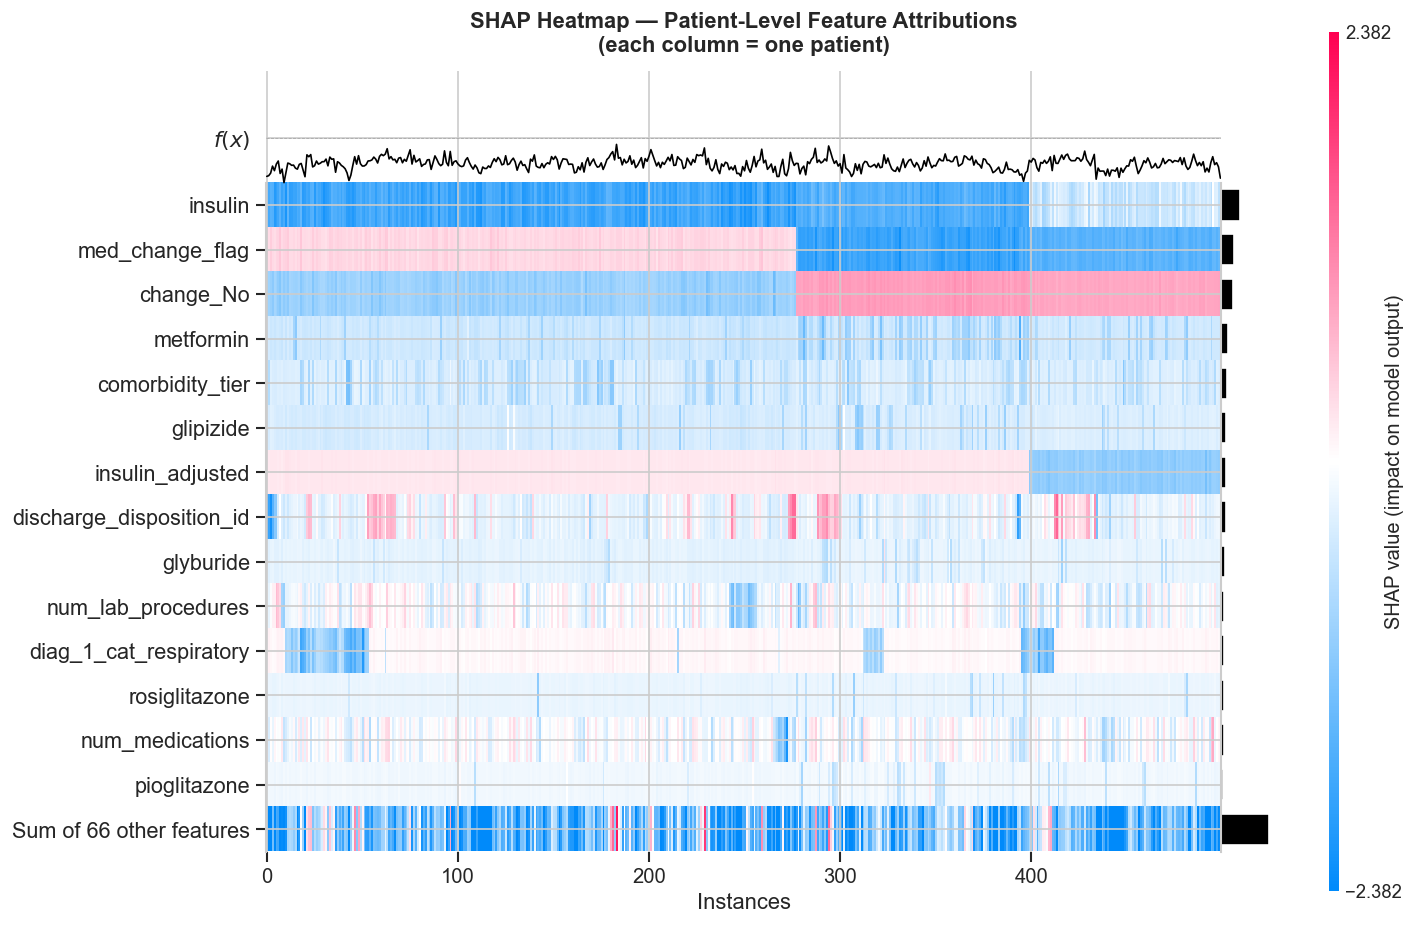

In [14]:
# ── SHAP Heatmap (subsample 500 for visual clarity) ───────────────────────────
sub_idx = np.random.choice(len(sv), min(500, len(sv)), replace=False)
sv_sub  = sv[sub_idx]

fig, ax = plt.subplots(figsize=(12, 7))
shap.plots.heatmap(
    sv_sub,
    max_display=15,
    show=False,
    plot_width=12
)
plt.title('SHAP Heatmap — Patient-Level Feature Attributions\n(each column = one patient)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plots/shap/03_heatmap.png', bbox_inches='tight')
plt.show()

---
## 6. Feature Interaction — Dependence Plots

**What it shows**: How a single feature's SHAP value changes as its raw value changes,
coloured by a second interacting feature. Reveals non-linearities and interactions the model learned.

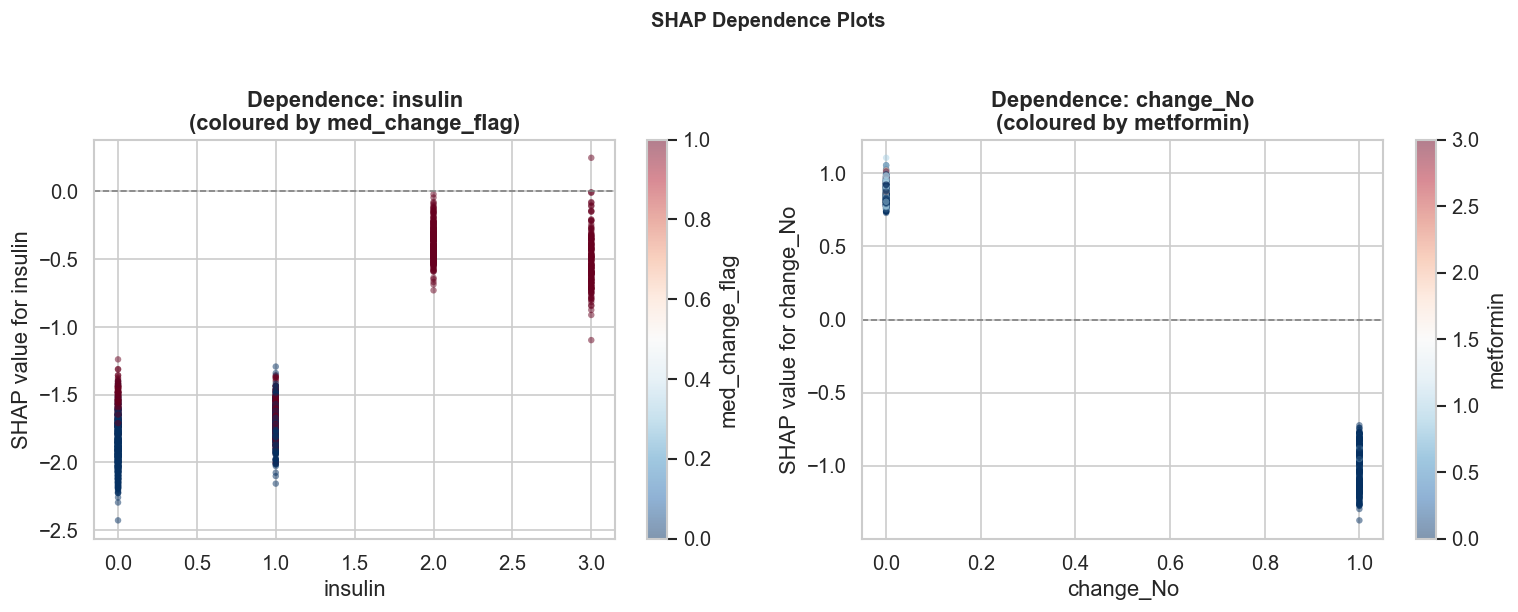

In [15]:
# ── Dependence Plot: Top Feature ──────────────────────────────────────────────
top_feat = top_features.index[0]  # highest mean |SHAP|
second_feat = top_features.index[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, interact in zip(axes,
    [top_feat, top_features.index[2]],
    [second_feat, top_features.index[3]]):

    feat_idx     = list(X_shap_for_plot.columns).index(feat)
    interact_idx = list(X_shap_for_plot.columns).index(interact)

    shap_feat    = sv.values[:, feat_idx]
    feat_vals    = X_shap_for_plot[feat].values
    interact_vals= X_shap_for_plot[interact].values

    sc = ax.scatter(feat_vals, shap_feat, c=interact_vals,
                    cmap='RdBu_r', alpha=0.5, s=15, edgecolors='none')
    plt.colorbar(sc, ax=ax, label=interact)
    ax.axhline(0, ls='--', color='gray', lw=1)
    ax.set_xlabel(feat)
    ax.set_ylabel(f'SHAP value for {feat}')
    ax.set_title(f'Dependence: {feat}\n(coloured by {interact})', fontweight='bold')

plt.suptitle('SHAP Dependence Plots', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/shap/04_dependence.png', bbox_inches='tight')
plt.show()

---
## 7. Per-Patient Explainability — Waterfall Plot

**What it shows**: For a single patient — how each feature *pushes* the prediction up or down
from the base rate. This is the plot you'd show a doctor explaining *why* a patient was flagged.

Red bars push toward readmission. Blue bars push away.

High-risk patient (idx 1284):
  Predicted probability : 0.920
  Actual label          : Not readmitted


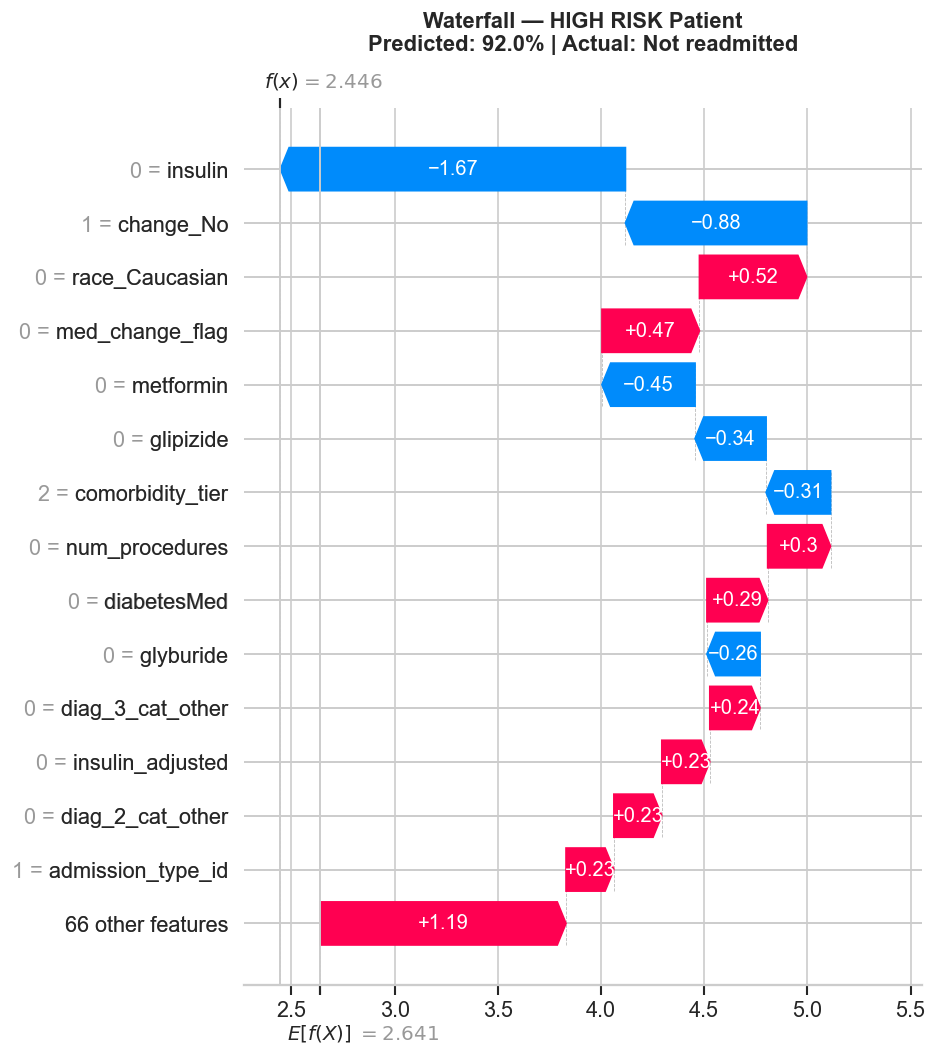

In [16]:
# ── Waterfall: High-Risk Patient ──────────────────────────────────────────────
y_prob_shap = model.predict_proba(X_shap)[:, 1]

# Pick patient with highest predicted readmission probability
high_risk_idx = np.argmax(y_prob_shap)
high_risk_prob = y_prob_shap[high_risk_idx]
high_risk_true = y_shap.iloc[high_risk_idx]

print(f'High-risk patient (idx {high_risk_idx}):')
print(f'  Predicted probability : {high_risk_prob:.3f}')
print(f'  Actual label          : {"Readmitted" if high_risk_true == 1 else "Not readmitted"}')

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(sv[high_risk_idx], max_display=15, show=False)
plt.title(f'Waterfall — HIGH RISK Patient\nPredicted: {high_risk_prob:.1%} | Actual: {"Readmitted" if high_risk_true==1 else "Not readmitted"}',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plots/shap/05_waterfall_high_risk.png', bbox_inches='tight')
plt.show()

Low-risk patient (idx 1259):
  Predicted probability : 0.000
  Actual label          : Not readmitted


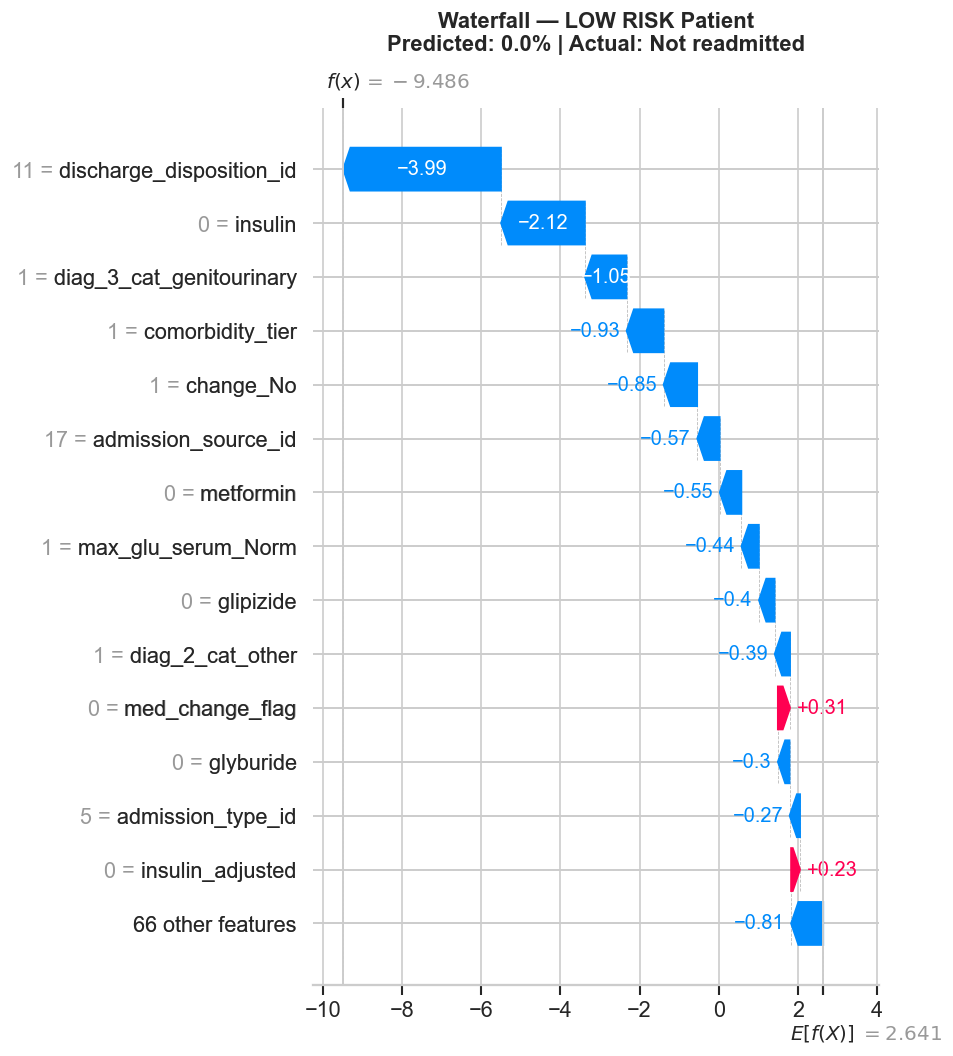

In [17]:
# ── Waterfall: Low-Risk Patient ───────────────────────────────────────────────
low_risk_idx  = np.argmin(y_prob_shap)
low_risk_prob = y_prob_shap[low_risk_idx]
low_risk_true = y_shap.iloc[low_risk_idx]

print(f'Low-risk patient (idx {low_risk_idx}):')
print(f'  Predicted probability : {low_risk_prob:.3f}')
print(f'  Actual label          : {"Readmitted" if low_risk_true == 1 else "Not readmitted"}')

fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.waterfall(sv[low_risk_idx], max_display=15, show=False)
plt.title(f'Waterfall — LOW RISK Patient\nPredicted: {low_risk_prob:.1%} | Actual: {"Readmitted" if low_risk_true==1 else "Not readmitted"}',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plots/shap/06_waterfall_low_risk.png', bbox_inches='tight')
plt.show()

---
## 8. Per-Patient Explainability — Force Plot

**What it shows**: Same as waterfall but in a compact horizontal format — great for dashboards
and the Streamlit app in Phase 5. Forces pushing right = toward readmission (red); left = away (blue).

In [18]:
# ── Force Plot: High-Risk Patient (renders in Jupyter) ────────────────────────
base_val = float(sv.base_values[0])

force_plot = shap.force_plot(
    base_val,
    sv.values[high_risk_idx],
    X_shap_for_plot.iloc[high_risk_idx],
    feature_names=feature_names,
    matplotlib=False   # set True to save as PNG
)
# Display inline in Jupyter
force_plot

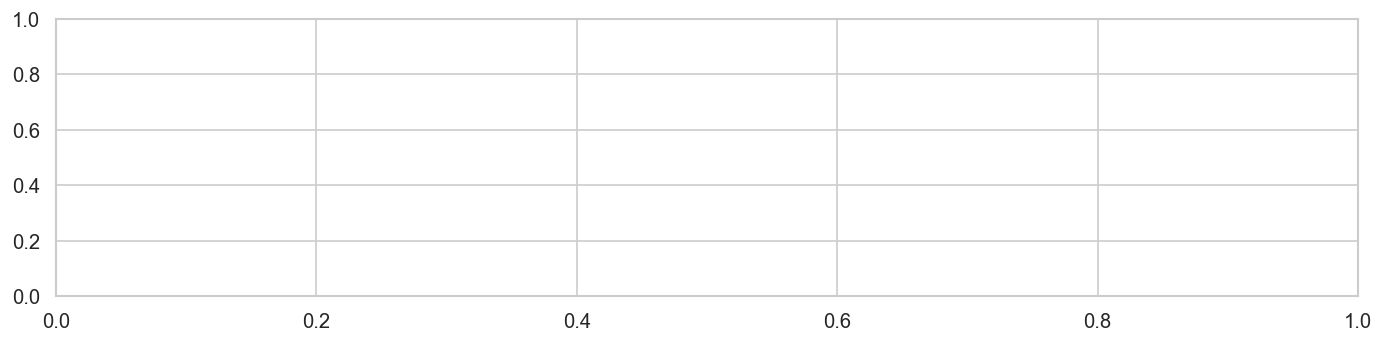

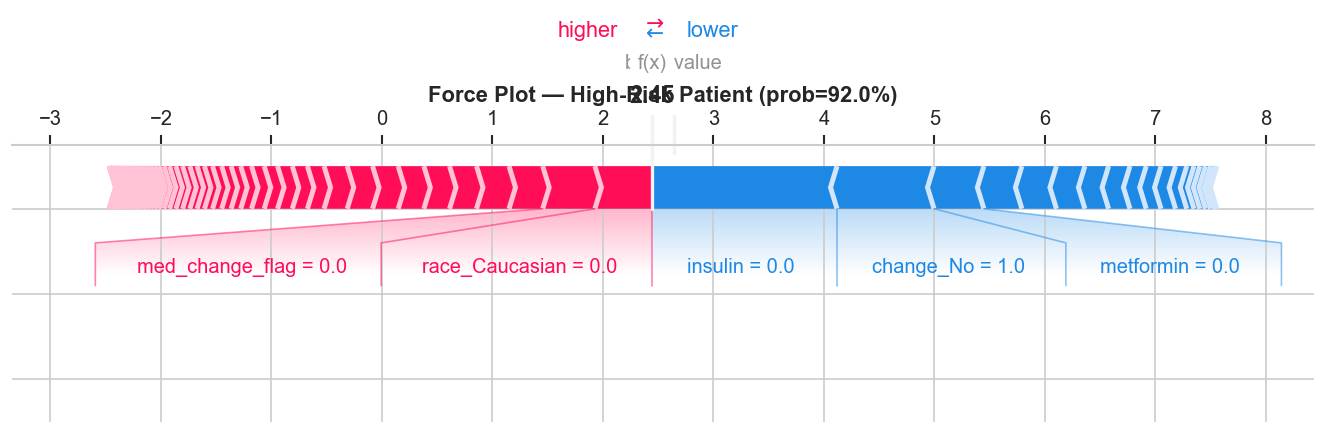

In [19]:
# ── Force Plot: Save as PNG (matplotlib=True) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
shap.force_plot(
    base_val,
    sv.values[high_risk_idx],
    X_shap_for_plot.iloc[high_risk_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=False,
    figsize=(14, 3)
)
plt.title(f'Force Plot — High-Risk Patient (prob={high_risk_prob:.1%})',
          fontweight='bold', y=1.12)
plt.savefig('plots/shap/07_force_plot_high_risk.png', bbox_inches='tight')
plt.show()

---
## 9. High-Risk vs Low-Risk Patient Comparison

Side-by-side breakdown of the top features for the highest and lowest risk patients.
This is compelling to put in a README or presentation — it tells a clinical story.

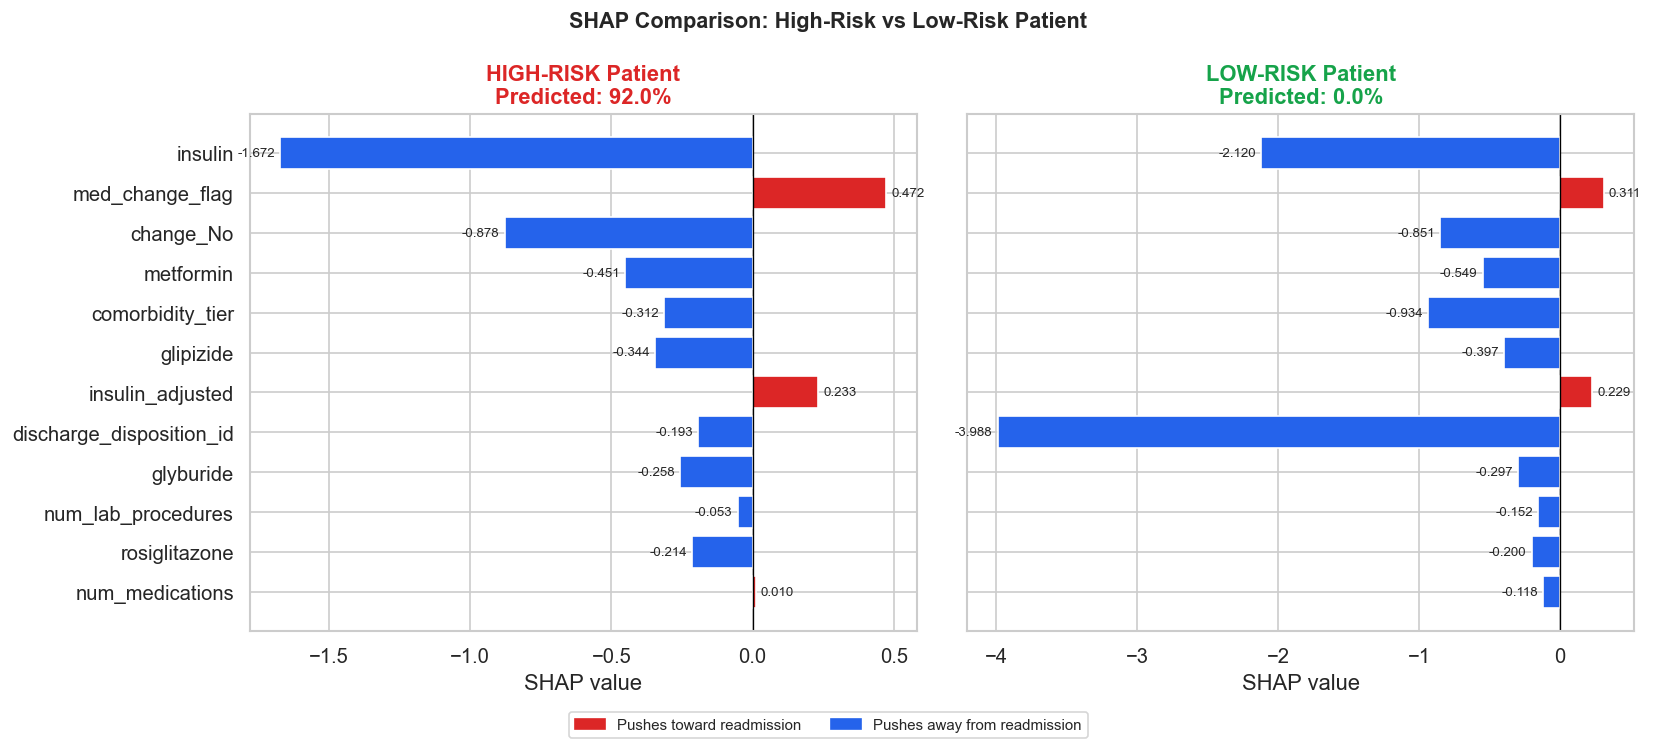

In [20]:
# ── Side-by-Side Feature Comparison ──────────────────────────────────────────
TOP_FEAT_N = 12
top_feat_names = top_features.index[:TOP_FEAT_N].tolist()

hr_shap = pd.Series(sv.values[high_risk_idx], index=feature_names)[top_feat_names]
lr_shap = pd.Series(sv.values[low_risk_idx],  index=feature_names)[top_feat_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, shap_vals, label, prob, color in zip(
    axes,
    [hr_shap, lr_shap],
    ['HIGH-RISK', 'LOW-RISK'],
    [high_risk_prob, low_risk_prob],
    ['#DC2626', '#16A34A']
):
    bar_colors = ['#DC2626' if v > 0 else '#2563EB' for v in shap_vals.values]
    bars = ax.barh(shap_vals.index[::-1], shap_vals.values[::-1],
                   color=bar_colors[::-1], edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{label} Patient\nPredicted: {prob:.1%}', fontweight='bold', color=color)
    ax.set_xlabel('SHAP value')
    ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=8)

red_patch  = mpatches.Patch(color='#DC2626', label='Pushes toward readmission')
blue_patch = mpatches.Patch(color='#2563EB', label='Pushes away from readmission')
fig.legend(handles=[red_patch, blue_patch], loc='lower center',
           ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.suptitle('SHAP Comparison: High-Risk vs Low-Risk Patient', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/shap/08_patient_comparison.png', bbox_inches='tight')
plt.show()

In [21]:
# ── Print Patient Profiles ────────────────────────────────────────────────────
print('HIGH-RISK Patient Profile (top features):')
print(X_shap_for_plot.iloc[high_risk_idx][top_feat_names].to_string())
print(f'\nPredicted readmission probability: {high_risk_prob:.1%}')
print(f'Actual outcome: {"Readmitted ✅" if high_risk_true==1 else "Not readmitted ❌"}')

print('\n' + '─'*50)
print('\nLOW-RISK Patient Profile (top features):')
print(X_shap_for_plot.iloc[low_risk_idx][top_feat_names].to_string())
print(f'\nPredicted readmission probability: {low_risk_prob:.1%}')
print(f'Actual outcome: {"Readmitted ✅" if low_risk_true==1 else "Not readmitted ❌"}')

HIGH-RISK Patient Profile (top features):
insulin                      0.0
med_change_flag              0.0
change_No                    1.0
metformin                    0.0
comorbidity_tier             2.0
glipizide                    0.0
insulin_adjusted             0.0
discharge_disposition_id     1.0
glyburide                    0.0
num_lab_procedures          45.0
rosiglitazone                0.0
num_medications              4.0

Predicted readmission probability: 92.0%
Actual outcome: Not readmitted ❌

──────────────────────────────────────────────────

LOW-RISK Patient Profile (top features):
insulin                      0.0
med_change_flag              0.0
change_No                    1.0
metformin                    0.0
comorbidity_tier             1.0
glipizide                    0.0
insulin_adjusted             0.0
discharge_disposition_id    11.0
glyburide                    0.0
num_lab_procedures          24.0
rosiglitazone                0.0
num_medications              8

---
## 10. Clinical Insights Summary

In [22]:
# ── Auto-generate Clinical Insights from SHAP ─────────────────────────────────
top5 = top_features.head(5)

print('═'*60)
print('CLINICAL INSIGHTS FROM SHAP ANALYSIS')
print('═'*60)
print()
print('TOP 5 READMISSION RISK DRIVERS:')
for i, (feat, val) in enumerate(top5.items(), 1):
    # Check direction: positive mean SHAP = higher values increase risk
    mean_shap = sv.values[:, list(X_shap_for_plot.columns).index(feat)].mean()
    direction = '↑ Higher value' if mean_shap > 0 else '↓ Lower value'
    print(f'  {i}. {feat}')
    print(f'     Mean |SHAP| = {val:.4f}  |  Direction: {direction} → increases risk')
    print()

print()
print('─'*60)
print('SHAP PLOTS SAVED:')
for f in sorted(os.listdir('plots/shap')):
    print(f'  plots/shap/{f}')

print()
print('─'*60)
print('NEXT → Phase 5: Streamlit Dashboard')
print('  • Patient input form → readmission probability')
print('  • Waterfall SHAP plot per prediction')
print('  • Deploy to Streamlit Cloud (free shareable link)')
print('═'*60)

════════════════════════════════════════════════════════════
CLINICAL INSIGHTS FROM SHAP ANALYSIS
════════════════════════════════════════════════════════════

TOP 5 READMISSION RISK DRIVERS:
  1. insulin
     Mean |SHAP| = 1.4969  |  Direction: ↓ Lower value → increases risk

  2. med_change_flag
     Mean |SHAP| = 0.9675  |  Direction: ↓ Lower value → increases risk

  3. change_No
     Mean |SHAP| = 0.9202  |  Direction: ↓ Lower value → increases risk

  4. metformin
     Mean |SHAP| = 0.5384  |  Direction: ↓ Lower value → increases risk

  5. comorbidity_tier
     Mean |SHAP| = 0.4553  |  Direction: ↓ Lower value → increases risk


────────────────────────────────────────────────────────────
SHAP PLOTS SAVED:
  plots/shap/01_global_bar.png
  plots/shap/02_beeswarm.png
  plots/shap/03_heatmap.png
  plots/shap/04_dependence.png
  plots/shap/05_waterfall_high_risk.png
  plots/shap/06_waterfall_low_risk.png
  plots/shap/07_force_plot_high_risk.png
  plots/shap/08_patient_comparison.png